### $\color{indianred}{\text{ASTROSTATISTIKA - v10}} $

<hr style="border: none; height: 2px; background-color: indianred; opacity: 0.5;" />

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson, iqr, cauchy
from scipy.integrate import simpson # pogledati...
import emcee # odličan MCMC modul

**Za uvod u temu bajesovskog zaključivanja, vidjeti knjigu od Ivezića i ostalih(str. 165) i predavanja. Ovaj notebook će biti dodatno izmijenjen.**

Pretpostavimo da imamo $N$ mjerenja, $x_i$. Greške mjerenja su gausovski raspoređene, pri čemu je greška mjerenja za svako mjerenje $\sigma_i$. Traži se posteriorna funkcija gustine vjerovatnoće kao $\mu : p(\mu|x_i, \sigma_i)$. Pošto se pretpostavlja da funkcija vjerodostojnosti za jedno mjerenje $x_i$ prati normalnu raspodjelu $\mathcal{N}(\mu, \sigma)$, za sva mjerenja imamo:

$$
p(x_i|\mu, \sigma, I) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi}\sigma} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right),
$$

pri čemu se $\sigma$ procjenjuje. Usvajajući uniformnu raspodjelu apriorne vjerovatnoće za parametar lokacije $\mu$ i uniformnu raspodjelu apriorne vjerovatnoće za $\ln\sigma$, važi:

$$
p(\mu, \sigma|I) \propto \frac{1}{\sigma}, \quad \mu_{\min} \le \mu \le \mu_{\max} \text{ i } \sigma_{\min} \le \sigma \le \sigma_{\max}.
$$

Dalje, slijedi:

$$
L_p = \text{const.} - (N+1)\ln\sigma - \frac{N}{2\sigma^2}\left((\bar{x} - \mu)^2 + V\right),
$$

gdje je $N$ veličina uzorka, a $V$ je definisano kao:

$$
V = N^{-1}\sum_{i=1}^{N}(x_i - \bar{x})^2 = \frac{(N-1)s^2}{N},
$$

pri čemu je $s$ standardna devijacija uzorka:

$$
s = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(x_i - \bar{x})^2},
$$

a $\bar{x}$ je aritmetička sredina uzorka:

$$
\bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i.
$$

Konkretno, u pokaznom primjeru, figurišu $\bar{x}$, $V$, $n$, $\sigma$ i $\mu$ kao parametri. 

In [29]:
def gaus_logL(xbar, V, n, sigma, mu): 
    return (-(n + 1) * np.log(sigma)
            - 0.5 * n * ((xbar - mu) ** 2 + V) / sigma ** 2)

def konverzija_stdev(logL): # log-posteriorna "površina" konvertuje se u mapu kumulativne vjerovatnoće 
    return 1 - np.exp(logL)

sigma = np.linspace(1, 5, 70)
mu = np.linspace(-3, 5, 70)
xbar = 1
V = 4
n = 10

logL = gaus_logL(xbar, V, n, sigma[:, np.newaxis], mu)
logL -= logL.max() # tzv. augmented assignment operator (pogledati)

Dakle, $L_p$ se evaluira za svaki par ($\mu,\sigma$).

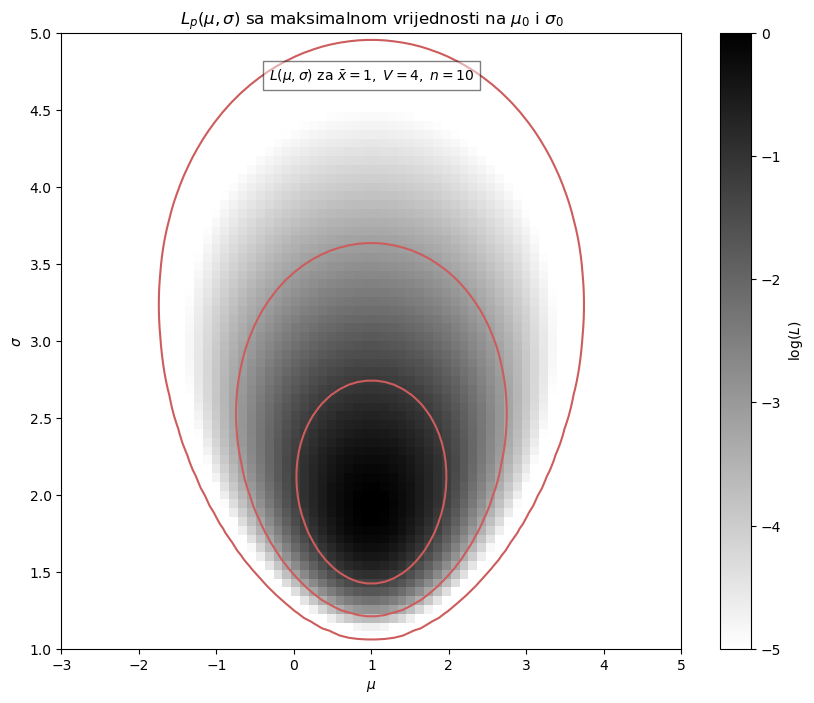

In [30]:
plt.figure(figsize=(10, 8))
plt.imshow(logL, origin='lower', extent=(mu[0], mu[-1], sigma[0], sigma[-1]), cmap='binary', aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)

plt.contour(mu, sigma, konverzija_stdev(logL), levels=(0.683, 0.955, 0.997), colors='indianred')
plt.text(0.5, 0.93, r'$L(\mu,\sigma)\ \mathrm{za}\ \bar{x}=1,\ V=4,\ n=10$', bbox=dict(ec='k', fc='w', alpha=0.5), ha='center', va='center', transform=plt.gca().transAxes)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.title(r'$L_p(\mu,\sigma)$ sa maksimalnom vrijednosti na $\mu_0$ i $\sigma_0$')
plt.show()

---

Sada, računamo posteriornu funkciju gustine raspodjele vjerovatnoće $p(\mu\,|\,x_i,I)$ koristeći sljedeću jednakost:

$$
p(\mu\,|\,x_i,I)\propto\Big[1+\frac{(\bar{x}-\mu)^2}{V}\Big]^{-N/2}.
$$

Takođe, može se naći i $p(\sigma\,|\,x_i,I)$ preko:

$$
p(\mu\,|\,x_i,I)\propto\frac{1}{\sigma^N}e^{\frac{-NV}{2\sigma^2}}.
$$

Naravno, oba ova rezultata se mogu porediti sa normalnom raspodjelom dobijenom iz $\bar{x}$, $\sigma_{\bar{x}}$, tj. iz $s$ i $\sigma_s$, respektivno (takođe,  sa bootstrap procjenama). Cilj nam je da uporedimo više pristupa za procjenu neodređenosti parametara - bajesovski (egzaktan *posterior*, dva izbora za *prior*), frekventistički (CGT) i bootstrap (neparametarsko reuzorkovanje). Ispod su dati očekivani analitički fitovi na posteriornu raspodjelu.

In [31]:
def racunaj_pmu(mu, xbar, V, n): 
    return (1 + (xbar - mu) ** 2 / V) ** (-0.5 * n)

def racunaj_pmu_alt(mu, xbar, V, n):
    return (1 + (xbar - mu) ** 2 / V) ** (-0.5 * (n - 1))

def racunaj_psig(sig, V, n):
    return (sig ** -n) * np.exp(-0.5 * n * V / sig ** 2)

def racunaj_psig_alt(sig, V, n):
    return (sig ** -(n - 1)) * np.exp(-0.5 * n * V / sig ** 2)

def gaus(x, mu, sigma):
    return np.exp(-0.5 * (x - mu) ** 2 / sigma ** 2)

dist = norm(0, 1)
r = dist.rvs(10) 
p = dist.pdf(0)

def m_sigma(x, ddof=1, axis=None):
    return np.mean(x, axis=axis), np.std(x, ddof=ddof, axis=axis)

n = 10
xbar = 1
V = 4
sigma_x = np.sqrt(V)

np.random.seed(10)
xi = np.random.normal(xbar, sigma_x, size=n)

mu_m, sig_m = m_sigma(xi)

mu_std = sig_m / np.sqrt(n)
sig_std = sig_m / np.sqrt(2 * (n - 1))

def m_std(x):
    return np.mean(x), np.std(x, ddof=1)

n_boot = int(1e6)
rng = np.random.default_rng(10)
ind = rng.integers(0, n, size=(n_boot, n))
boot_samp = xi[ind]

mu_bootstrap = np.std(boot_samp.mean(axis=1), ddof=1)
sig_bootstrap = np.std(boot_samp.std(axis=1, ddof=1), ddof=1)

In [32]:
mu = np.linspace(-3, 5, 1000)
dmu = mu[1] - mu[0]

pmu = racunaj_pmu(mu, 1, 4, 10)
pmu /= (dmu * pmu.sum())

pmu2 = racunaj_pmu_alt(mu, 1, 4, 10)
pmu2 /= (dmu * pmu2.sum())

pmu_norm = gaus(mu, mu_m, mu_std)
pmu_norm /= (dmu * pmu_norm.sum())

boot_mu_dist  = boot_samp.mean(axis=1)
boot_sig_dist = boot_samp.std(axis=1, ddof=1)

mu_bootstrap  = np.std(boot_mu_dist, ddof=1)   
sig_bootstrap = np.std(boot_sig_dist, ddof=1)

mu_hist,  mu_bins  = np.histogram(boot_mu_dist, 20)
mu_dbin = np.diff(mu_bins).astype(float)
mu_hist = mu_hist / mu_dbin / mu_hist.sum()

sig_hist, sig_bins = np.histogram(boot_sig_dist, 20)  
sig_dbin = np.diff(sig_bins).astype(float)
sig_hist = sig_hist / sig_dbin / sig_hist.sum()

sig = np.linspace(1e-4, 8, 1000)
dsig = sig[1] - sig[0]
psig = racunaj_psig(sig, 4, 10)
psig /= (dsig * psig.sum())

psig2 = racunaj_psig_alt(sig, 4, 10)
psig2 /= (dsig * psig2.sum())

psig_norm = gaus(sig, sig_m, sig_std)
psig_norm /= (dsig * psig_norm.sum())

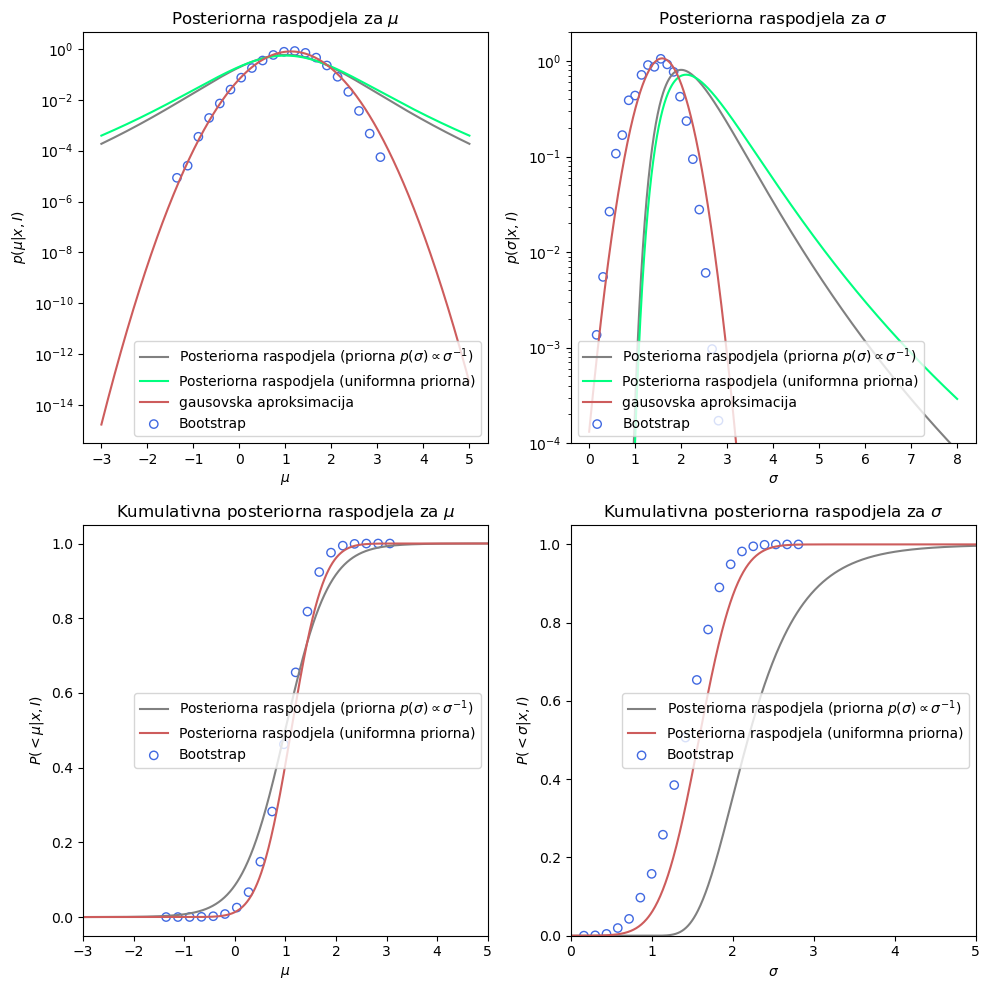

In [33]:
fig = plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.yscale('log')
plt.plot(mu, pmu, color='gray', label='Posteriorna raspodjela (priorna $p(\sigma)\propto\sigma^{-1})$')
plt.plot(mu, pmu2, color='springgreen', label='Posteriorna raspodjela (uniformna priorna)')
plt.plot(mu, pmu_norm, color='indianred', label='gausovska aproksimacija')
plt.scatter(mu_bins[1:] - 0.5 * mu_dbin, mu_hist, edgecolor='royalblue', facecolor='none', label='Bootstrap')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(\mu|x,I)$')
plt.title(r'Posteriorna raspodjela za $\mu$')
plt.legend()
plt.subplot(223)
plt.plot(mu, pmu.cumsum() * dmu, color='gray', label='Posteriorna raspodjela (priorna $p(\sigma)\propto\sigma^{-1})$')
plt.plot(mu, pmu_norm.cumsum() * dmu, color='indianred', label='Posteriorna raspodjela (uniformna priorna)')
plt.scatter(mu_bins[1:] - 0.5 * mu_dbin, mu_hist.cumsum() * mu_dbin, edgecolor='royalblue', facecolor='none', label='Bootstrap') # num. integracija pdf
plt.xlim(-3, 5)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$P(<\mu|x,I)$')
plt.title(r'Kumulativna posteriorna raspodjela za $\mu$')
plt.legend()
plt.subplot(222)
plt.yscale('log')
plt.plot(sig, psig, color='gray', label='Posteriorna raspodjela (priorna $p(\sigma)\propto\sigma^{-1})$')
plt.plot(sig, psig2, color='springgreen', label='Posteriorna raspodjela (uniformna priorna)')
plt.plot(sig, psig_norm, color='indianred', label='gausovska aproksimacija')
plt.scatter(sig_bins[1:] - 0.5 * sig_dbin, sig_hist, edgecolor='royalblue', facecolor='none', label='Bootstrap')
plt.ylim(1e-4, 2)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$p(\sigma|x,I)$')
plt.title(r'Posteriorna raspodjela za $\sigma$')
plt.legend()
plt.subplot(224)
plt.plot(sig, psig.cumsum() * dsig, color='gray', label='Posteriorna raspodjela (priorna $p(\sigma)\propto\sigma^{-1})$')
plt.plot(sig, psig_norm.cumsum() * dsig, color='indianred', label='Posteriorna raspodjela (uniformna priorna)')
plt.scatter(sig_bins[1:] - 0.5 * sig_dbin, sig_hist.cumsum() * sig_dbin, edgecolor='royalblue', facecolor='none', label='Bootstrap')
plt.ylim(0, 1.05)
plt.xlim(0, 5)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$P(<\sigma|x,I)$')
plt.title(r'Kumulativna posteriorna raspodjela za $\sigma$')
plt.legend()
plt.tight_layout()
plt.show()

---

Kada su greške mjerenja heteroskedastične, rezultujuća raspodjela mjerenja više nije normalna, već linearna superpozicija normalnih raspodjela sa širinama $\sqrt{1 + e_i^2}$. Cilj je istražiti kako se ova raspodjela ponaša u poređenju sa normalnom, koristeći iste statističke alate kao ranije.

In [34]:
np.random.seed(0)
Npts = int(1e6)
x = np.random.normal(loc=0, scale=1, size=Npts)
e = 3 * np.random.random(Npts)
x += np.random.normal(0, e)

def med_sigmaG(x):
    med = np.median(x)
    sigG = 0.7413 * iqr(x)
    return med, sigG

def m_sigma(x):
    return np.mean(x), np.std(x, ddof=1)

mu_samp, sig_samp = m_sigma(x)
med_samp, sigG_samp = med_sigmaG(x)

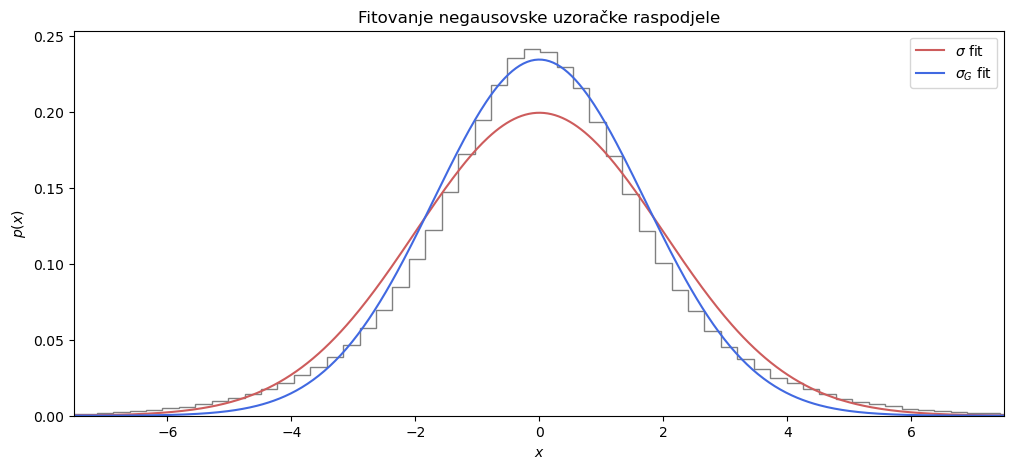

In [35]:
plt.figure(figsize=(12, 5))
plt.hist(x, 100, histtype='step', color='grey', density=True)

x_samp = np.linspace(-15, 15, 1000)
plt.plot(x_samp, norm(mu_samp, sig_samp).pdf(x_samp), color='indianred', label=r'$\sigma$ fit')
plt.plot(x_samp, norm(med_samp, sigG_samp).pdf(x_samp), color='royalblue', label=r'$\sigma_G$ fit')
plt.legend()
plt.xlim(-7.5, 7.5)
plt.xlabel('$x$')
plt.ylabel('$p(x)$')
plt.title('Fitovanje negausovske uzoračke raspodjele')
plt.show()

---

Kada svako mjerenje $x_i$ ima svoju poznatu grešku $e_i$, onda je efektivna varijansa za svaku tačku $\sigma^2 + e_i^2$. To mijenja oblik log-posteriorne raspodjele:

$$
L_p = \text{const.} - \frac{1}{2}\sum_{i=1}^{N}\left(\ln(\sigma^2 + e_i^2) + \frac{(x_i - \mu)^2}{\sigma^2 + e_i^2}\right).
$$

In [36]:
def gausgaus_logL(xi, ei, mu, sigma):

    ndim = len(np.broadcast(sigma, mu).shape)
    xi = xi.reshape(xi.shape + tuple(ndim * [1]))
    ei = ei.reshape(ei.shape + tuple(ndim * [1]))
    s2_e2 = sigma ** 2 + ei ** 2
    return -0.5 * np.sum(np.log(s2_e2) + (xi - mu) ** 2 / s2_e2, 0)

np.random.seed(5)
mu_p = 1.
sigma_p = 1.
N = 10
ei = 3 * np.random.random(N)
xi = np.random.normal(mu_p, np.sqrt(sigma_p ** 2 + ei ** 2))

sigma = np.linspace(0.01, 5, 70)
mu = np.linspace(-3, 5, 70)

logL = gausgaus_logL(xi, ei, mu, sigma[:, np.newaxis])
logL -= logL.max()

Cilj je vidjeti kako poznate (ali različite) greške mjerenja mijenjaju oblik posteriorne raspodjele.

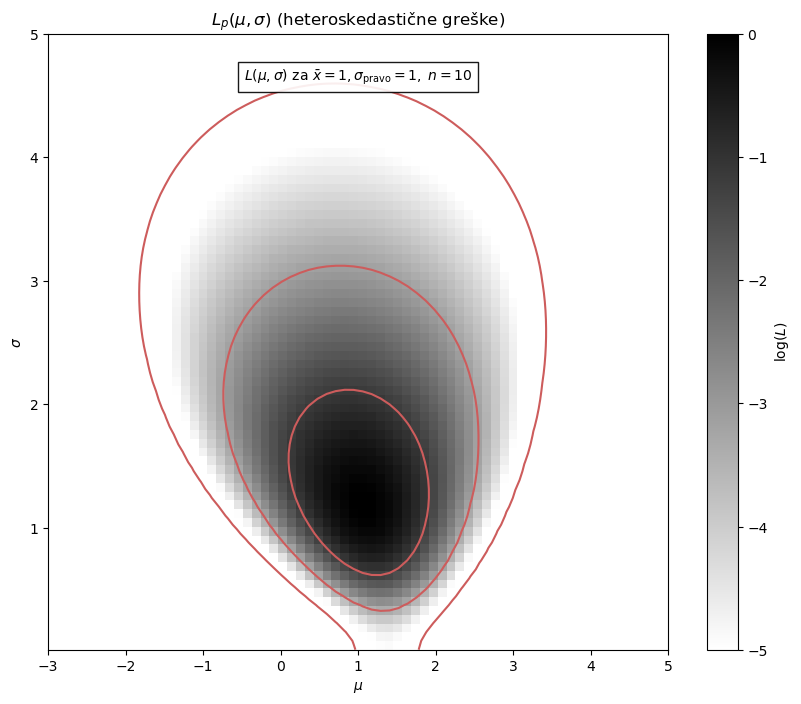

In [37]:
plt.figure(figsize=(10, 8))
plt.imshow(logL, origin='lower', extent=(mu[0], mu[-1], sigma[0], sigma[-1]), cmap='binary', aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)

plt.text(0.5, 0.93, (r'$L(\mu,\sigma)\ \mathrm{za}\ \bar{x}=1, \sigma_{\rm pravo}=1,\ n=10$'), bbox=dict(ec='k', fc='w', alpha=0.9), ha='center', va='center', transform=plt.gca().transAxes)
plt.contour(mu, sigma, konverzija_stdev(logL), levels=(0.683, 0.955, 0.997), colors='indianred')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.title(r'$L_p(\mu,\sigma)$ (heteroskedastične greške)')
plt.show()

---

$\blacksquare$ **P1**: $\mathcal{F}$ vs $\mathcal{B}$

Teleskop je uperen u nebo i posmatra svjetlost koja dolazi od jedne zvijezde. Pretpostavlja se da je fluks konstantan u vremenu; dakle ima fiksiranu vrijednost $F_t$. Vrši se $N$ mjerenja, gdje fluksu $F_i$ odgovaraju greške $e_i$. Pošto je dat skup mjerenja $D=\{F_i,e_i\}$, pitanje je koja je najbolja procjena $F_t$. Ovdje je Poasonova raspodjela dobra aproksimacija procesa mjerenja. Greške su gausovskog tipa. U frekventističkoj paradigmi, ovo znači da je $e_i$ standardna devijacija rezultata jednog mjerenja. U bajesovskoj paradigmi, $e_i$ je standardna devijacija normalne raspodjele vjerovatnoće, koja opisuje naše poznavanje pojedinačnog mjerenja, uzevši u obzir posmatranu vrijednost. 

In [38]:
np.random.seed(1)
Ft = 1000 # pravi flux; broj fotona detektovanih/izmjerenih u 1s
N = 50 # broj mjerenja
F = poisson(Ft).rvs(N) # N mjerenja fluksa
e = np.sqrt(F) # greške 

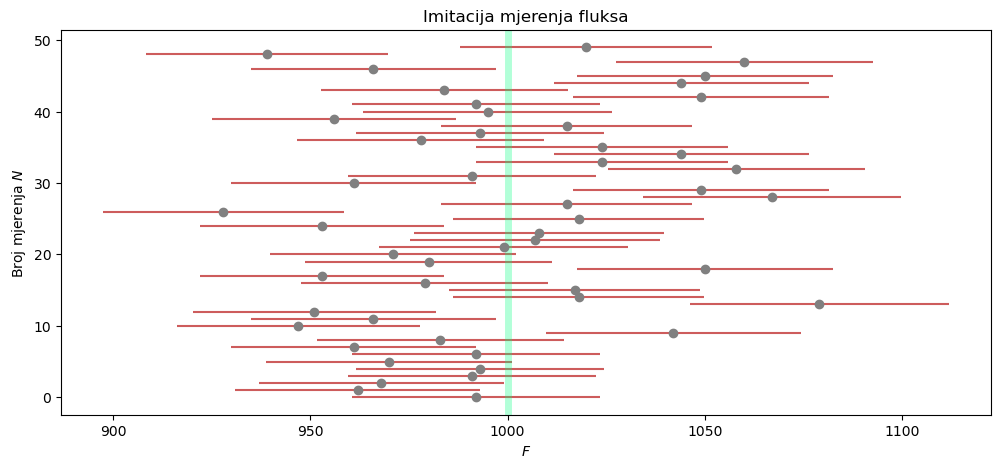

In [39]:
plt.figure(figsize=(12,5))
plt.errorbar(F, np.arange(N), xerr=e, fmt='o', color='gray', ecolor='indianred')
plt.axvline([Ft], 0, N, lw=5, alpha=0.3, color='springgreen')
plt.xlabel(r'$F$')
plt.ylabel(r'Broj mjerenja $N$')
plt.title('Imitacija mjerenja fluksa')
plt.show()

Mjerenja imaju različite greške $e_i$, koje su procijenjene Poasonovom statistikom. Napomena - traži se najbolja procjena $F_t$ uzevši u obzir mjerenja i greške.

**Frekventistički pristup**: dato je jedno mjerenje $D_i=(F_i,e_i)$, što znači da se može izračunati raspodjela vjerovatnoće:

$$
p(D_i\,|\,F_t)=\frac{1}{\sqrt{2\pi e_i^2}}e^{\frac{-(F_i-F_t)^2}{2e_i^2}}.
$$

Naravno, dalje se procjenjuje maksimalna vjerodostojnost:

$$
\mathcal{L}(D\,|\,F_t)=\prod_{i=1}^Np(D_i\,|\,F_t)\iff \log{\mathcal{L}}=-\frac{1}{2}\sum_{i=1}^N\Big[\log{(2\pi e_i^2)}+\frac{(F_i-F_t)^2}{e_i^2}\Big].
$$

Dalje imamo:

$$
\frac{d\log{L}}{dF_t}=0\implies F_e =\frac{\sum\omega_i F_i}{\omega_i},\,\,\omega_i=1/e_i^2,
$$

gdje je $F_e$ procijenjeni fluks. Kad su greške $e_i$ jednake, onda se ovo svodi na $F_e=\frac{1}{N}\sum_{i=1}^NF_i$, gdjje je $F_e$ jednostavno procijenjena oteženjena srednja vrijednost fluksa. Što se tiče procijenjene greške, proizlazi sljedeća jednakost:

$$
\sigma_e=\Big(\sum_{i=1}^N\omega_i\Big)^{-1/2}.
$$

In [40]:
w = 1. / e ** 2
# samo fensi print
print(""" 
      Ft = {0}
      Fe  = {1:.0f} +/- {2:.0f} (bazirano na {3} mjerenja)
      """.format(Ft, (w * F).sum() / w.sum(), w.sum() ** -0.5, N))

 
      Ft = 1000
      Fe  = 998 +/- 4 (bazirano na 50 mjerenja)
      


**Bajesovski pristup**: vjerovatnoće vezane za parametre modela nemaju smisla u frekventističkoj filozofiji, ali su skroz prihvatljive u bajesovskoj. U ovom zadatku, traži se:

$$
p(F_t\,|\,D)=\frac{p(D\,|\,F_t)p(F_t)}{p(D)}.
$$

Ukratko, $p(F_t\,|\,D)$ jeste posteriorna raspodjela, $p(D\,|\,F_t)$ je priorna raspodjela (proporcionalna $\mathcal{L}(D\,|\,F_t)$), $p(F_t)$ je prior modela (šta znamo o modelu prije primjene na skup podataka $D$) i $p(D)$ je vjerovatnoća podataka (vezano za normalizaciju). Ukoliko se npr. uzme $p(F_t)\propto1$, onda se dobija $p(F_t\,|\,D)\propto\mathcal{L}(D\,|\,F_t)$. Bajesovska vjerovatnoća je u ovom slučaju maksimizovana i daje istu vrijednost kao frekventistička. Još jednom, odabir $p(F_t)$ jeste jako važan dio (treba izbjeći subjektivan odabir jer tome nije mjesto u statistici - naravno, prior može da bude i *neinformativan* [ovo su neke od glavnih zamjerki frekventista]). U slučaju jednoparametarskih problema, računanje $p(F_t\,|\,D)$ jeste jednostavno. Međutim, kako raste broj dimenzija modela, ovaj pristup postaje sve lošija opcija. Bajesovski izračuni zato često koriste *Markov Chain Monte Carlo* (MCMC) metode uzorkovanja. Cilj je generisati podatke iz posteriorne raspodjele vjerovatnoće, te ih iskoristiti za procjenu tražene veličine.

In [41]:
def log_prior(theta):
    return 1  

def log_likelihood(theta, F, e):
    return -0.5 * np.sum(np.log(2 * np.pi * e ** 2) + (F - theta[0]) ** 2 / e ** 2)

def log_posterior(theta, F, e):
    return log_prior(theta) + log_likelihood(theta, F, e)

In [42]:
ndim = 1  # broj parametara modela
nw = 50  # MCMC "walkers"
nb = 1000  # "burn-in" period za stabilizaciju
ns = 2000  # broj MCMC koraka
sg = 2000 * np.random.rand(nw, ndim)

sampler = emcee.EnsembleSampler(nw, ndim, log_posterior, args=[F, e])
sampler.run_mcmc(sg, ns)
samp = sampler.chain  # shape = (nw, ns, ndim)
samp = sampler.chain[:, nb:, :].ravel()  

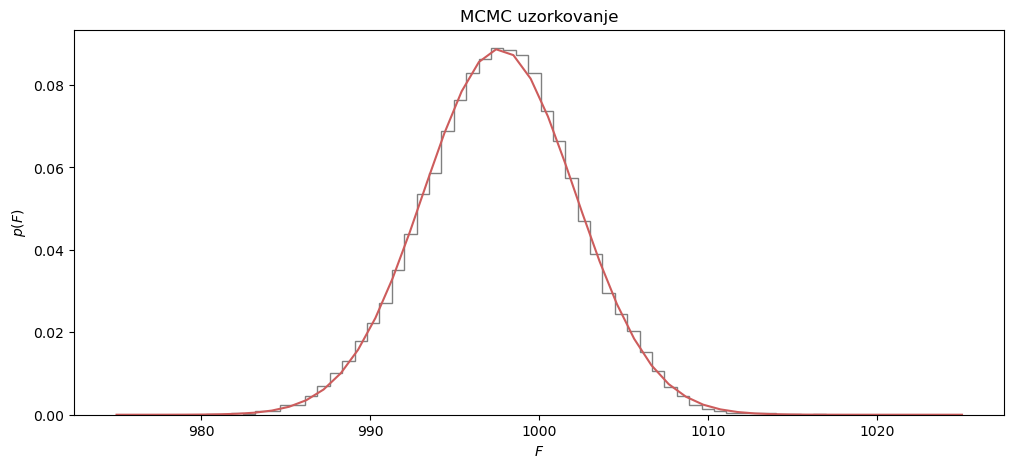

In [43]:
plt.figure(figsize=(12,5))
plt.hist(samp, bins=50, histtype='step', color='gray', density=True)

F_fit = np.linspace(975, 1025) 
pdf = norm(np.mean(samp), np.std(samp)).pdf(F_fit)

plt.plot(F_fit, pdf, color='indianred')
plt.xlabel(r'$F$')
plt.ylabel(r'$p(F)$')
plt.title('MCMC uzorkovanje')
plt.show()

In [44]:
print("""
      Ft = {0}
      Fe  = {1:.0f} +/- {2:.0f} (bazirano na {3} mjerenja)
      """.format(Ft, np.mean(samp), np.std(samp), N))


      Ft = 1000
      Fe  = 998 +/- 4 (bazirano na 50 mjerenja)
      


S obzirom na to je u pitanju jednostavan primjer, bilo je za očekivati da će rezultati biti identični. Važno je naglasiti da je za isticanje bajesovskih rezultata potrebno ostaviti posteriornu raspodjelu samu po sebi (ovaj posljednji ispis je frekventistički opis posteriora)! Primjer bi bio kompletniji ukoliko bi se uzelo da fluks zvijezde varira u vremenu. U tom slučaju bi bilo moguće definisati dvoparametarski gausovski model $\theta=[\mu,\sigma]$, te bi fluks bio:

$$
F_t\sim\frac{1}{\sqrt{2\pi\sigma^2}}e^{\frac{-(F-\mu)^2}{2\sigma^2}}.
$$

Ovo se može uraditi za vježbu. Potrebne su male izmjene funkcija iznad.

---

Da se podjsetimo, binomna raspodjela opisuje broj uspjeha $k$ u $N$ pokušaja sa vjerovatnoćom uspjeha $b$:

$$
p(k|b, N) = \frac{N!}{k!(N-k)!}\ b^k(1-b)^{N-k}.
$$

Za poznato $k$ i $N$, posteriorna raspodjela po $b$ (uz uniformnu priornu) je:

$$
p(b|k, N) = C\, b^k(1-b)^{N-k}.
$$

In [45]:
n = 7
k = 4

b = np.linspace(0, 1, 100)
db = b[1] - b[0]

p_b = b ** k * (1 - b) ** (n - k)
p_b /= p_b.sum()
p_b /= db
cuml_p_b = p_b.cumsum()
cuml_p_b /= cuml_p_b[-1]

sigma_b = np.sqrt(k / n * (1 - k / n) / n)
p_g = norm(k / n, sigma_b).pdf(b)
cuml_p_g = p_g.cumsum()
cuml_p_g /= cuml_p_g[-1]

Za malo $N$, gausovska aproksimacija je loša - prava posteriorna raspodjela je asimetrična. Za veće $N$, to se mijenja (opet CGT).

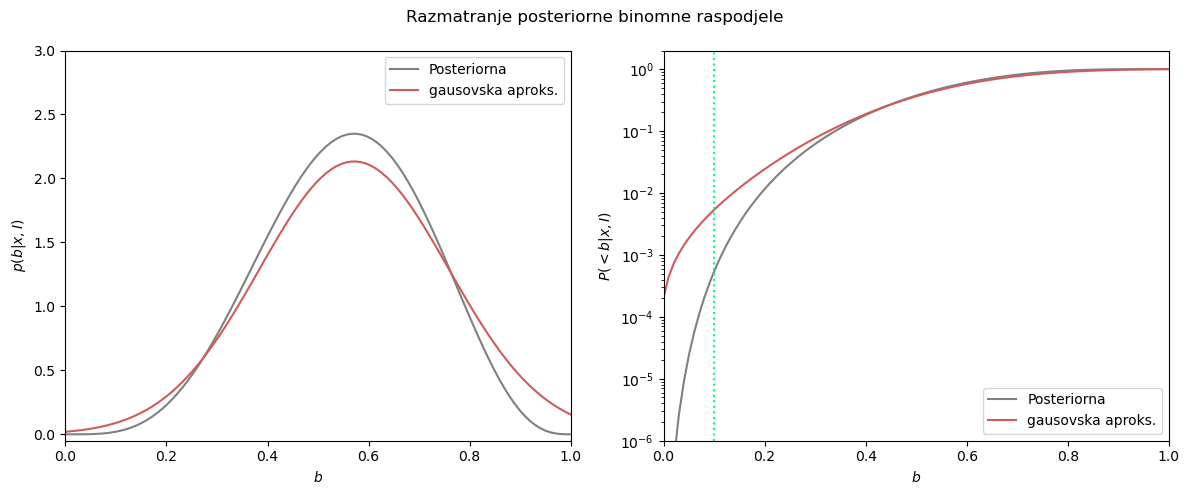

In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(b, p_b, color='gray', label='Posteriorna')
plt.plot(b, p_g, color='indianred', label='gausovska aproks.')
plt.ylim(-0.05, 3)
plt.xlim(0, 1)
plt.xlabel('$b$')
plt.ylabel('$p(b|x,I)$')
plt.legend()

plt.subplot(122)
plt.yscale('log')
plt.plot(b, cuml_p_b, color='gray', label='Posteriorna')
plt.plot(b, cuml_p_g, color='indianred', label='gausovska aproks.')
plt.plot([0.1, 0.1], [1e-6, 2], color='springgreen', ls=':')
plt.xlabel('$b$')
plt.ylabel('$P(<b|x,I)$')
plt.ylim(1e-6, 2)
plt.xlim(0, 1)
plt.legend()
plt.suptitle('Razmatranje posteriorne binomne raspodjele')
plt.tight_layout()
plt.show()

---
Pretpostavimo da imamo $N$ pokušaja od kojih je $k$ uspješnih. Vjerovatnoća uspjeha je $b$, a funkcija vjerodostojnosti dobijamo preko posteriorne raspodjele po $b$:

$$
L_p(b|k,N) = \ln p(b|k,N) = k\ln b + (N-k)\ln(1-b).
$$

In [47]:
def bi_logL(b, k, n):
    return k * np.log(b) + (n - k) * np.log(1 - b)

n = 7
b = np.linspace(0.001, 0.999, 70)
k = np.linspace(0, n, 70)

logL = bi_logL(b, k[:, np.newaxis], n)
logL -= logL.max()

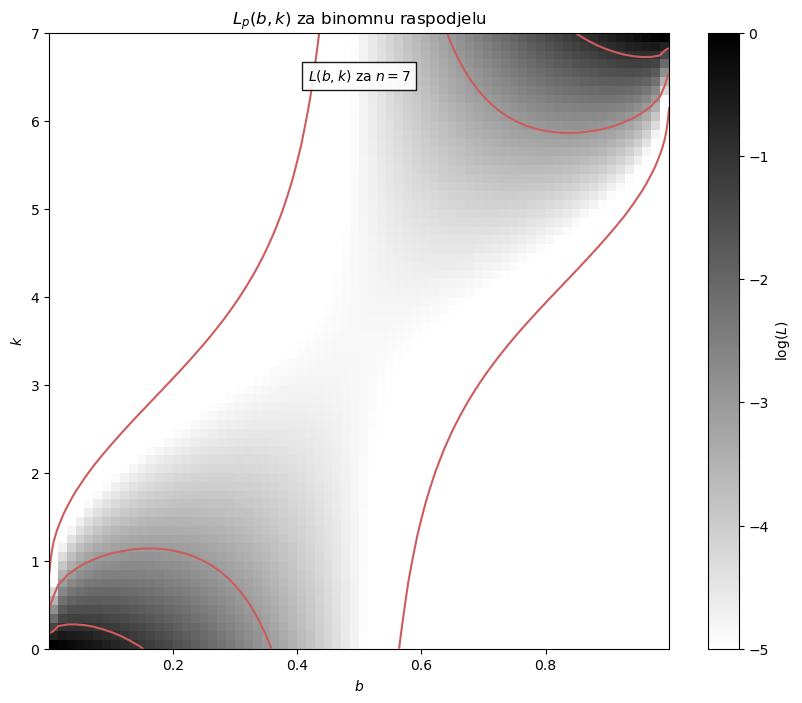

In [48]:
plt.figure(figsize=(10, 8))
plt.imshow(logL, origin='lower', extent=(b[0], b[-1], k[0], k[-1]), cmap='binary', aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)

plt.contour(b, k, konverzija_stdev(logL), levels=(0.683, 0.955, 0.997), colors='indianred')
plt.text(0.5, 0.93, rf'$L(b,k)\ \mathrm{{za}}\ n={n}$', bbox=dict(ec='k', fc='w', alpha=0.9), ha='center', va='center', transform=plt.gca().transAxes)

plt.xlabel(r'$b$')
plt.ylabel(r'$k$')
plt.title(r'$L_p(b,k)$ za binomnu raspodjelu')
plt.show()

---

Košijeva raspodjela je simetrična raspodjela sa parametrima lokacije $\mu$ i skale $\gamma$:

$$
p(x|\mu, \gamma) = \frac{1}{\pi\gamma}\left(\frac{\gamma^2}{\gamma^2 + (x-\mu)^2}\right).
$$

Pošto joj repovi opadaju kao $x^{-2}$, srednja vrijednost i standardna devijacija *ne postoje*, pa ne možemo koristiti uobičajene estimatore. Umjesto toga možemo da iskoristimo bajesovski pristup. Za skup mjerenja $\{x_i\}$ imamo:

$$
p(x_i|\mu, \gamma, I) = \prod_{i=1}^{N} \frac{1}{\pi}\left(\frac{\gamma}{\gamma^2 + (x_i-\mu)^2}\right).
$$

Uz uniformnu priornu raspodjelu za $\mu$ i $\ln\gamma$, slijedi:

$$
L_p \equiv\ln{[p(\mu,\gamma\,|\,x_i,I)]}=\text{const} + (N-1)\ln\gamma - \sum_{i=1}^{N}\ln[\gamma^2 + (x_i - \mu)^2].
$$

In [49]:
def kosi_logL(xi, gama, mu):

    xi = np.asarray(xi)
    n = xi.size
    shape = np.broadcast(gama, mu).shape
    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    return ((n - 1) * np.log(gama) - np.sum(np.log(gama ** 2 + (xi - mu) ** 2), 0))

gama = np.linspace(0.1, 5, 70)
mu = np.linspace(-5, 5, 70)

np.random.seed(2)
mu0 = 0
gama0 = 2
xi = cauchy(mu0, gama0).rvs(10)
logL = kosi_logL(xi, gama[:, np.newaxis], mu)
logL -= logL.max()

In [50]:
i, j = np.where(logL >= np.max(logL))

# L se poredi sa "medijanom i IQR" rezultatom
print(mu[j])
print(gama[i])
print()

med, sigG = med_sigmaG(xi)
print(med)
print(sigG / 1.483)
print()

[-0.65217391]
[0.66811594]

-0.8455045350831584
0.6521096365959547



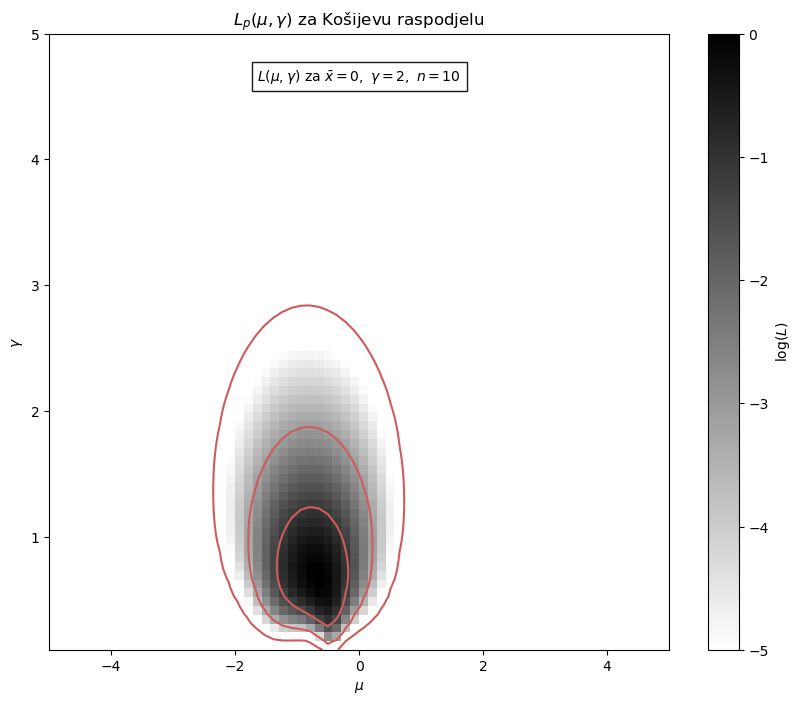

In [51]:
plt.figure(figsize=(10, 8))
plt.imshow(logL, origin='lower', cmap='binary', extent=(mu[0], mu[-1], gama[0], gama[-1]), aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)

plt.contour(mu, gama, konverzija_stdev(logL), levels=(0.683, 0.955, 0.997), colors='indianred')
plt.text(0.5, 0.93, r'$L(\mu,\gamma)\ \mathrm{za}\ \bar{x}=0,\ \gamma=2,\ n=10$', bbox=dict(ec='k', fc='w', alpha=0.9), ha='center', va='center', transform=plt.gca().transAxes)

plt.xlabel(r'$\mu$')
plt.ylabel(r'$\gamma$')
plt.title('$L_p(\mu,\gamma)$ za Košijevu raspodjelu')
plt.show()

--- 
Bajesova teorema se koristi u ažuriranju našeg znanja o parametru $\mu$ nakon dobijanja mjerenja $x$ sa greškom $e$, uz gausovski *prior* $\mathcal{N}(\mu_0, \sigma_0)$ Posteriorna raspodjela je proizvod dva gausijana (*likelihood* $\times$ *prior*):

$$
p(\mu\,|\,x, e, \mu_0, \sigma_0) \propto \frac{1}{e\sqrt{2\pi}}e^{\frac{-(μ-x)^2}{2e^2}} \cdot \frac{1}{\sigma_0\sqrt{2\pi}}e^{\frac{-(\mu-\mu_0)^2}{2\sigma_0^2}}.
$$

Proizvod dva gausijana je ponovo gausijan, pa se posteriorna raspodjela može zapisati kao:

$$
p(\mu\,|\,x, e, \mu_0, \sigma_0) = \frac{1}{\sigma_p\sqrt{2\pi}}e^{\frac{-(\mu-\mu_p)^2}{2\sigma_p^2}},
$$

gdje su posteriorna srednja vrijednost i standardna devijacija određene preko:

$$
\mu_p = \frac{(x/e^2) + (\mu_0/\sigma_0^2)}{1/e^2 + 1/\sigma_0^2}, \qquad \sigma_p = \left(\frac{1}{e^2} + \frac{1}{\sigma_0^2}\right)^{-1/2}.
$$

Težinska sredina mjerenja $x$ je $\mu_p$, a *priora* $\mu_0$, pri čemu veća preciznost (manji $e$ ili $\sigma_0$) nosi veću težinu. Posteriorna raspodjela je uvijek uža, tj. kombinovanje informacija smanjuje neodređenost.

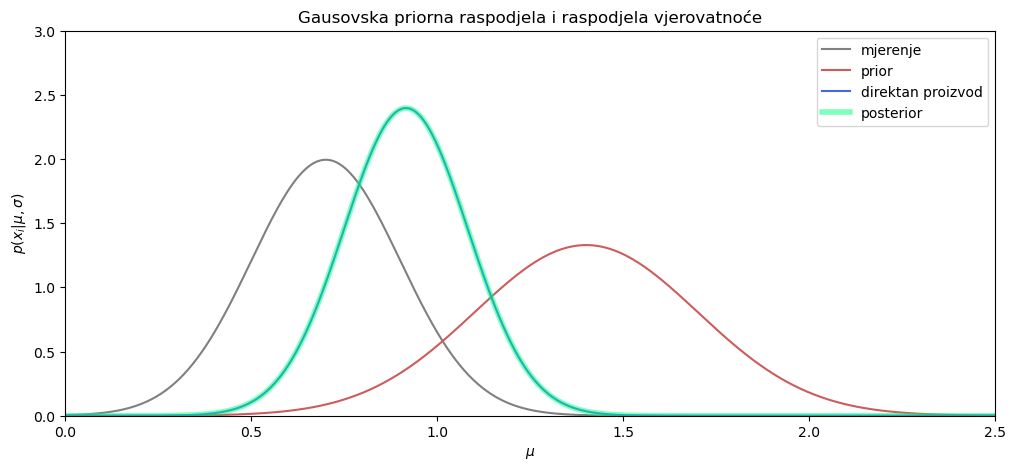

In [52]:
# tzv. conjugate prior
x = 0.7 
e = 0.2
mu0 = 1.4
sigma0 = 0.3 
mug = np.linspace(0,3,1000)
n1 = norm(x, e).pdf(mug) 
n2 = norm(mu0, sigma0).pdf(mug) 
P = n1 * n2 
P = P/simpson(P, mug)

sigma_p = 1/np.sqrt(1/e**2+1/sigma0**2)
mu_p = (x/e**2 + mu0/sigma0**2)*sigma_p**2
posterior = norm(mu_p, sigma_p).pdf(mug) 

plt.figure(figsize=(12, 5))
plt.plot(mug, n1, color='gray', label=r'mjerenje')
plt.plot(mug, n2, color='indianred', label=r'prior')
plt.plot(mug, P, color='royalblue', label=r'direktan proizvod')
plt.plot(mug, posterior, color='springgreen', lw=4, alpha=0.5, label=r'posterior')
plt.xlim(0.0, 2.5)
plt.ylim(0, 3.0)
plt.xlabel('$\mu$')
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.title('Gausovska priorna raspodjela i raspodjela vjerovatnoće')
plt.legend()
plt.show() 

---

$\blacksquare$ **P2**: Posmatramo radijalne brzine $N$ zvijezda u skupini sa heteroskedastičnim greškama mjerenja $e_i$. Pretpostavljamo da je prava brzina svake zvijezde izvučena iz normalne raspodjele $\mathcal{N}(\mu, \sigma)$, gdje je $\mu$ sistemska brzina skupa, a $\sigma$ disperzija brzina - oboje su nepoznati. Budući da greške nisu iste za sve zvijezde, ne postoji analitičko rješenje, pa koristimo tzv. hijerarhijski bajesovski model: $\mu$ i $\sigma$ su hiperparametri koji zajednički opisuju populaciju, a sva mjerenja zajedno ih bolje ograničavaju nego bilo koje pojedinačno. Posteriorne procjene pravih brzina pojedinačnih zvijezda su *stisnute* prema skupnoj sredini - efekat poznat kao *shrinkage*.

In [53]:
def g_logL(xi, ei, mu, sigma):
    ndim = len(np.broadcast(sigma, mu).shape)
    xi = xi.reshape(xi.shape + tuple(ndim * [1]))
    ei = ei.reshape(ei.shape + tuple(ndim * [1]))
    s2_e2 = sigma ** 2 + ei ** 2
    return -0.5 * np.sum(np.log(s2_e2) + (xi - mu) ** 2 / s2_e2, 0)

def expstD(x, p):
    Ex = np.sum(x * p) / np.sum(p)
    Sx = np.sqrt(np.sum((x - Ex) ** 2 * p) / np.sum(p))
    return Ex, Sx

np.random.seed(2)
N = 10
mu_p = -50.0
sigma_p = 20.0
ei = 10 + 40 * np.random.random(N)
xi = np.random.normal(mu_p, np.sqrt(sigma_p ** 2 + ei ** 2))

wi = 1 / ei ** 2 / np.sum(1 / ei ** 2)
wm = np.sum(wi * xi)

sigma = np.linspace(0.01, 120, 70)
mu = np.linspace(-150, 50, 70)

logL = g_logL(xi, ei, mu, sigma[:, np.newaxis])
logL -= logL.max()
L = np.exp(logL)

p_sigma = L.sum(1)
p_sigma /= (sigma[1] - sigma[0]) * p_sigma.sum()

p_mu = L.sum(0)
p_mu /= (mu[1] - mu[0]) * p_mu.sum()

Ev, Sv = expstD(mu, p_mu)
Ed, Sd = expstD(sigma, p_sigma)
mup, sigp = Ev, Ed

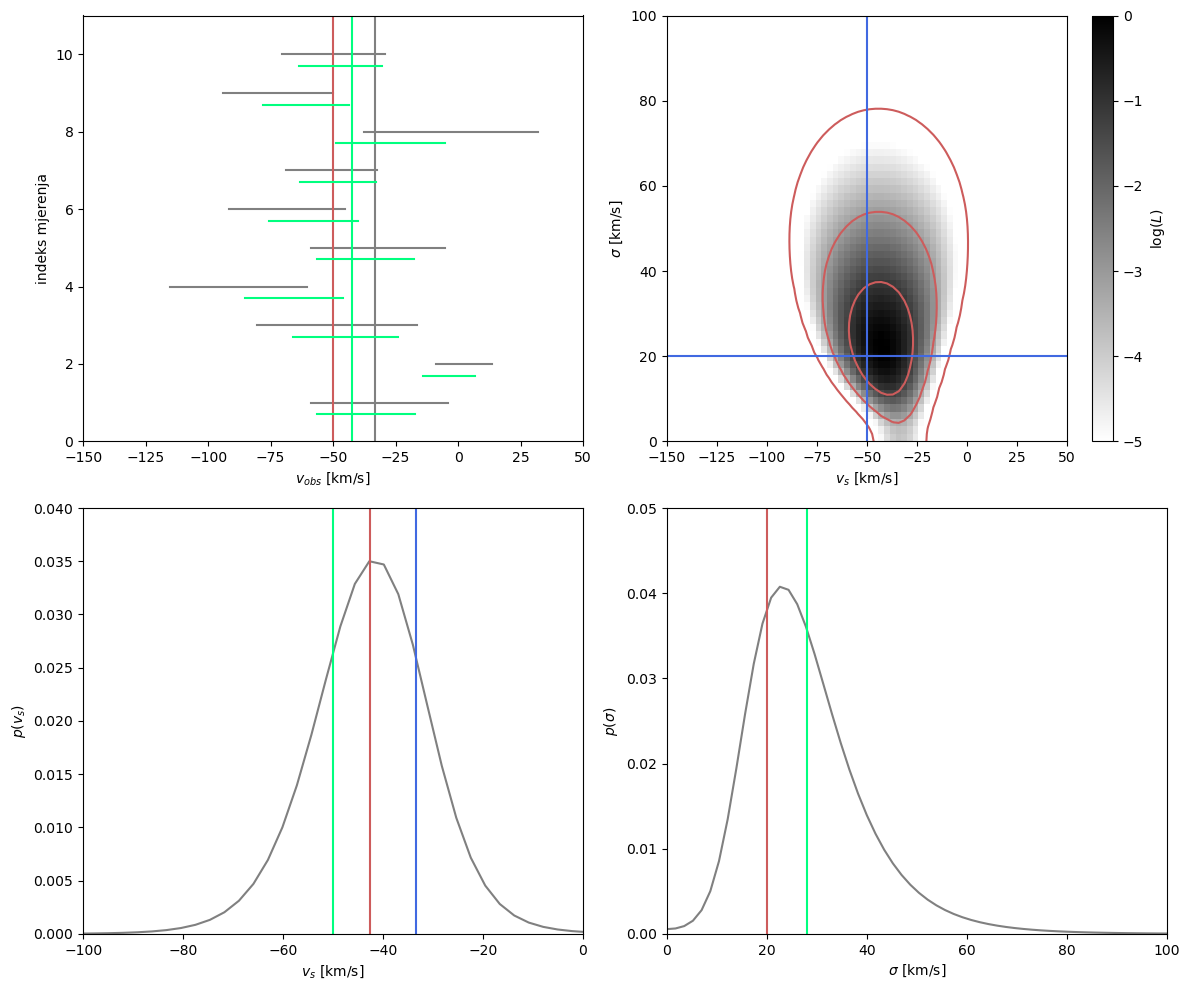

In [54]:
plt.figure(figsize=(12, 10))

plt.subplot(221)
plt.xlabel(r'$v_{obs}$ [km/s]')
plt.ylabel(r'indeks mjerenja')
plt.xlim(-150, 50)
plt.ylim(0, 11)
for i in range(N):
    plt.plot([xi[i] - ei[i], xi[i] + ei[i]], [i + 1, i + 1], color='gray')
plt.plot([wm, wm], [0, 11], color='gray')
plt.plot([mu_p, mu_p], [0, 11], color='indianred')
for i in range(N):
    sig0 = 1 / np.sqrt(1 / sigp ** 2 + 1 / ei[i] ** 2)
    mu0 = (mup / sigp ** 2 + xi[i] / ei[i] ** 2) * sig0 ** 2
    plt.plot([mu0 - sig0, mu0 + sig0], [i + 0.7, i + 0.7], color='springgreen')
plt.plot([mup, mup], [0, 11], color='springgreen')

plt.subplot(222)
plt.imshow(logL, origin='lower', extent=(mu[0], mu[-1], sigma[0], sigma[-1]), cmap='binary', aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)
plt.contour(mu, sigma, konverzija_stdev(logL), levels=(0.683, 0.955, 0.997), colors='indianred')
plt.xlabel(r'$v_s$ [km/s]')
plt.ylabel(r'$\sigma$ [km/s]')
plt.xlim(-150, 50.0)
plt.ylim(0, 100)
plt.plot([mu_p, mu_p], [0, 100], color='royalblue')
plt.plot([-200, 200], [sigma_p, sigma_p], color='royalblue')

plt.subplot(223)
plt.plot(mu, p_mu, color='gray')
plt.xlabel(r'$v_s$ [km/s]')
plt.ylabel(r'$p(v_s)$')
plt.xlim(-100, 0.0)
plt.ylim(0, 0.04)
plt.plot([Ev, Ev], [0, 0.04], color='indianred')
plt.plot([mu_p, mu_p], [0, 0.04], color='springgreen')
plt.plot([wm, wm], [0, 0.04], color='royalblue')

plt.subplot(224)
plt.plot(sigma, p_sigma, color='gray')
plt.xlabel(r'$\sigma$ [km/s]')
plt.ylabel(r'$p(\sigma)$')
plt.xlim(0, 100.0)
plt.ylim(0, 0.05)
plt.plot([sigma_p, sigma_p], [0, 0.05], color='indianred')
plt.plot([Ed, Ed], [0, 0.05], color='springgreen')

plt.tight_layout()
plt.show()